# MAgent2 MF-DSRQ Torch Evaluation

Evaluate trained MF-DSRQ torch robust-epsilon checkpoints against PyTorch MFRL baselines on `battle_v4`. Each epsilon cell compares MF-DSRQ against IQL, AC, and MFQ with both red/blue side assignments.

In [1]:
from pathlib import Path
import json
import os
import sys

import pandas as pd
import torch


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "discrete_action_space").is_dir() and (path / "requirements.txt").exists():
            return path
    raise RuntimeError("Could not find the SRE-DQN repo root from the current notebook directory.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from discrete_action_space.mean_field_dsrq.notebook_utils import (
    evaluate_mfdsrq_torch_epsilon_fixed_side_tournament,
    find_latest_mfrl_run,
    load_mfdsrq_config,
    mfdsrq_epsilon_config,
    plot_fixed_side_tournament_bars,
)

MAP_SIZE = 40
MAX_CYCLES = 400
SEED = 42
ROBUST_DISTANCE = "tv"
ROBUST_LP_FALLBACK = "greedy_tv"
ROBUST_POLICY_TEMPERATURE = 0.1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EVAL_EPISODES_PER_MATCHUP = 100
TOURNAMENT_ALGORITHMS = ("mfdsrq", "iql", "ac", "mfq")
BASELINE_ALGORITHMS = tuple(algorithm for algorithm in TOURNAMENT_ALGORITHMS if algorithm != "mfdsrq")
EVAL_WORKERS = 1 if DEVICE == "cuda" else min(6, os.cpu_count() or 1)
EVAL_EPISODE_CHUNK_SIZE = 100
EVAL_SHOW_PROGRESS = True
EVAL_MAX_STEPS = MAX_CYCLES
TRAINING_PLOT_SMOOTHING_WINDOW = 50

RUNS_ROOT = ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
MFDSRQ_OUTPUT_ROOT = RUNS_ROOT / "mf_srq_torch_epsilon_training"
MFDSRQ_DECAY_OUTPUT_ROOT = RUNS_ROOT / "mf_srq_torch_epsilon_decay_to_zero"
MFDSRQ_RAMP_OUTPUT_ROOT = RUNS_ROOT / "mf_srq_torch_epsilon_ramp_up"
BASELINE_ROOT = RUNS_ROOT / "mfrl_baselines"

BASE_CFG = load_mfdsrq_config(
    overrides={
        "algorithm": "mf_srq_torch",
        "env_name": "battle_v4",
        "env_backend": "magent2",
        "map_size": MAP_SIZE,
        "max_cycles": MAX_CYCLES,
        "output_dir": str(MFDSRQ_OUTPUT_ROOT),
        "seed": SEED,
        "device": DEVICE,
        "use_gpu": DEVICE == "cuda",
        "robust_distance": ROBUST_DISTANCE,
        "robust_lp_fallback": ROBUST_LP_FALLBACK,
        "robust_policy_temperature": ROBUST_POLICY_TEMPERATURE,
    },
)


def epsilon_slug(epsilon):
    text = f"{float(epsilon):g}".replace(".", "_").replace("-", "neg_")
    return f"eps_{text}"


def schedule_slug(epsilon_start, epsilon_end):
    return f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")


def seed_run_dir(output_dir):
    return Path(output_dir) / "battle_v4" / f"seed{SEED}"


def checkpoint_paths_for_run(run_dir):
    run_dir = Path(run_dir)
    return {
        "main": run_dir / "ckpt_main_best.pt",
        "opponent": run_dir / "ckpt_opponent_best.pt",
    }


def fixed_epsilon_spec(epsilon):
    cfg = mfdsrq_epsilon_config(BASE_CFG, epsilon, MFDSRQ_OUTPUT_ROOT)
    run_dir = seed_run_dir(Path(cfg["output_dir"]))
    return {
        "group": "fixed",
        "epsilon": float(epsilon),
        "epsilon_for_eval": float(epsilon),
        "label": f"fixed eps={epsilon:g}",
        "cfg": cfg,
        "run_dir": run_dir,
        "checkpoint_paths": checkpoint_paths_for_run(run_dir),
    }


def scheduled_epsilon_spec(group, epsilon_start, epsilon_end, output_root):
    slug = schedule_slug(epsilon_start, epsilon_end)
    cfg = dict(BASE_CFG)
    cfg.update({
        "epsilon_robust_start": float(epsilon_start),
        "epsilon_robust_end": float(epsilon_end),
        "epsilon_robust_decay_frac": 1.0,
        "output_dir": str(Path(output_root) / slug),
    })
    run_dir = seed_run_dir(Path(cfg["output_dir"]))
    arrow = "decay" if group == "decay_to_zero" else "ramp"
    return {
        "group": group,
        "epsilon": float(epsilon_end),
        "epsilon_for_eval": float(epsilon_end),
        "label": f"{arrow} eps {epsilon_start:g}->{epsilon_end:g}",
        "cfg": cfg,
        "run_dir": run_dir,
        "checkpoint_paths": checkpoint_paths_for_run(run_dir),
    }


MFDSRQ_MODEL_SPECS = {
    "fixed_0_01": fixed_epsilon_spec(0.01),
    "fixed_0_1": fixed_epsilon_spec(0.1),
    "fixed_0_5": fixed_epsilon_spec(0.5),
    "fixed_1_0": fixed_epsilon_spec(1.0),
    "decay_0_5_to_0": scheduled_epsilon_spec("decay_to_zero", 0.5, 0.0, MFDSRQ_DECAY_OUTPUT_ROOT),
    "decay_0_75_to_0": scheduled_epsilon_spec("decay_to_zero", 0.75, 0.0, MFDSRQ_DECAY_OUTPUT_ROOT),
    "decay_1_0_to_0": scheduled_epsilon_spec("decay_to_zero", 1.0, 0.0, MFDSRQ_DECAY_OUTPUT_ROOT),
    "ramp_0_01_to_0_5": scheduled_epsilon_spec("ramp_up", 0.01, 0.5, MFDSRQ_RAMP_OUTPUT_ROOT),
    "ramp_0_01_to_1_0": scheduled_epsilon_spec("ramp_up", 0.01, 1.0, MFDSRQ_RAMP_OUTPUT_ROOT),
    "ramp_0_1_to_0_5": scheduled_epsilon_spec("ramp_up", 0.1, 0.5, MFDSRQ_RAMP_OUTPUT_ROOT),
    "ramp_0_1_to_1_0": scheduled_epsilon_spec("ramp_up", 0.1, 1.0, MFDSRQ_RAMP_OUTPUT_ROOT),
}

FIXED_MODEL_KEYS = ("fixed_0_01", "fixed_0_1", "fixed_0_5", "fixed_1_0")
DECAY_TO_ZERO_MODEL_KEYS = ("decay_0_5_to_0", "decay_0_75_to_0", "decay_1_0_to_0")
RAMP_UP_MODEL_KEYS = ("ramp_0_01_to_0_5", "ramp_0_01_to_1_0", "ramp_0_1_to_0_5", "ramp_0_1_to_1_0")
ALL_MODEL_KEYS = FIXED_MODEL_KEYS + DECAY_TO_ZERO_MODEL_KEYS + RAMP_UP_MODEL_KEYS

BASELINE_RUN_DIRS = {
    algorithm: find_latest_mfrl_run(algorithm, BASELINE_ROOT)
    for algorithm in BASELINE_ALGORITHMS
}
TOURNAMENTS = {}


def evaluate_and_plot_model(model_key):
    spec = MFDSRQ_MODEL_SPECS[model_key]
    tournament = evaluate_mfdsrq_torch_epsilon_fixed_side_tournament(
        spec["cfg"],
        spec["epsilon_for_eval"],
        spec["checkpoint_paths"],
        baseline_root=BASELINE_ROOT,
        algorithms=TOURNAMENT_ALGORITHMS,
        baseline_folders=BASELINE_RUN_DIRS,
        num_episodes_per_matchup=EVAL_EPISODES_PER_MATCHUP,
        max_steps=EVAL_MAX_STEPS,
        workers=EVAL_WORKERS,
        episode_chunk_size=EVAL_EPISODE_CHUNK_SIZE,
        show_progress=EVAL_SHOW_PROGRESS,
        save=True,
        device=DEVICE,
        experiment_label=spec["label"],
    )
    tournament["model_key"] = model_key
    tournament["model_label"] = spec["label"]
    _ = plot_fixed_side_tournament_bars(tournament, save=True)
    return tournament


def load_training_stats(model_key):
    stats_path = MFDSRQ_MODEL_SPECS[model_key]["run_dir"] / "training_stats.json"
    if not stats_path.exists():
        print(f"Skipping {model_key}: no training_stats.json at {stats_path}")
        return None
    with open(stats_path, encoding="utf-8") as f:
        return json.load(f)


def load_baseline_training_stats(algorithm):
    stats_path = Path(BASELINE_RUN_DIRS[algorithm]) / "training_stats.json"
    if not stats_path.exists():
        print(f"Skipping {algorithm}: no training_stats.json at {stats_path}")
        return None
    with open(stats_path, encoding="utf-8") as f:
        return json.load(f)


def wins_from_record(record, team):
    if "wins" in record:
        return int(record["wins"].get(team, 0))
    if "winner" in record:
        return int(record.get("winner") == team)
    kills = record.get("kills", {})
    teams = list(record.get("rewards", {}).keys()) or ["main", "opponent"]
    team_kills = {name: int(kills.get(name, 0)) for name in teams}
    if not team_kills:
        return 0
    max_kills = max(team_kills.values())
    return int(team_kills.get(team, 0) == max_kills and list(team_kills.values()).count(max_kills) == 1)


def history_frame_from_stats(stats):
    if stats is None:
        return pd.DataFrame()
    records = stats.get("episode_records") or stats.get("records", [])
    rows = []
    for record in records:
        rows.append({
            "episode": record.get("episode", len(rows) + 1),
            "env_idx": record.get("env_idx", 0),
            "reward_main": record.get("rewards", {}).get("main", 0.0),
            "reward_opponent": record.get("rewards", {}).get("opponent", 0.0),
            "win_main": wins_from_record(record, "main"),
            "win_opponent": wins_from_record(record, "opponent"),
            "kills_main": record.get("kills", {}).get("main", 0),
            "kills_opponent": record.get("kills", {}).get("opponent", 0),
        })
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows).sort_values(["episode", "env_idx"]).reset_index(drop=True)
    df["episode_index"] = range(1, len(df) + 1)
    df["cum_win_main"] = df["win_main"].cumsum()
    df["cum_win_opponent"] = df["win_opponent"].cumsum()
    return df


def training_history_frame(model_key):
    return history_frame_from_stats(load_training_stats(model_key))


def baseline_training_history_frame(algorithm):
    return history_frame_from_stats(load_baseline_training_stats(algorithm))


def training_history_series(model_keys):
    series = []
    for model_key in model_keys:
        spec = MFDSRQ_MODEL_SPECS[model_key]
        series.append((spec["label"], training_history_frame(model_key)))
    for algorithm in BASELINE_ALGORITHMS:
        series.append((algorithm.upper(), baseline_training_history_frame(algorithm)))
    return series


def plot_training_history_group(model_keys, title, save_name, smoothing_window=TRAINING_PLOT_SMOOTHING_WINDOW, save=True):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(3, 2, figsize=(16, 11))
    axes = axes.reshape(3, 2)
    for label, df in training_history_series(model_keys):
        if df.empty:
            continue
        axes[0, 0].plot(
            df["episode_index"],
            df["reward_main"].rolling(smoothing_window, min_periods=1).mean(),
            label=label,
        )
        axes[0, 1].plot(
            df["episode_index"],
            df["reward_opponent"].rolling(smoothing_window, min_periods=1).mean(),
            label=label,
        )
        axes[1, 0].plot(df["episode_index"], df["cum_win_main"], label=label)
        axes[1, 1].plot(df["episode_index"], df["cum_win_opponent"], label=label)
        axes[2, 0].plot(
            df["episode_index"],
            df["kills_main"].rolling(smoothing_window, min_periods=1).mean(),
            label=label,
        )
        axes[2, 1].plot(
            df["episode_index"],
            df["kills_opponent"].rolling(smoothing_window, min_periods=1).mean(),
            label=label,
        )

    axes[0, 0].set_title(f"Main training rewards, rolling mean {smoothing_window}")
    axes[0, 1].set_title(f"Opponent training rewards, rolling mean {smoothing_window}")
    axes[1, 0].set_title("Main cumulative wins")
    axes[1, 1].set_title("Opponent cumulative wins")
    axes[2, 0].set_title(f"Main kills, rolling mean {smoothing_window}")
    axes[2, 1].set_title(f"Opponent kills, rolling mean {smoothing_window}")
    for ax in axes.ravel():
        ax.set_xlabel("Completed episode")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    if save:
        out_path = MFDSRQ_OUTPUT_ROOT / f"{save_name}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Saved training history plot to {out_path}")
    return fig

{
    "baseline_root": str(BASELINE_ROOT),
    "device": DEVICE,
    "cuda_available": torch.cuda.is_available(),
    "tournament_algorithms": TOURNAMENT_ALGORITHMS,
    "eval_episodes_per_matchup": EVAL_EPISODES_PER_MATCHUP,
    "eval_workers": EVAL_WORKERS,
    "eval_episode_chunk_size": EVAL_EPISODE_CHUNK_SIZE,
    "training_plot_smoothing_window": TRAINING_PLOT_SMOOTHING_WINDOW,
    "model_specs": {
        key: {
            "label": spec["label"],
            "run_dir": str(spec["run_dir"]),
            "checkpoint_paths": {team: str(path) for team, path in spec["checkpoint_paths"].items()},
        }
        for key, spec in MFDSRQ_MODEL_SPECS.items()
    },
}


{'baseline_root': '/home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mfrl_baselines',
 'device': 'cuda',
 'cuda_available': True,
 'tournament_algorithms': ('mfdsrq', 'iql', 'ac', 'mfq'),
 'eval_episodes_per_matchup': 100,
 'eval_workers': 1,
 'eval_episode_chunk_size': 100,
 'training_plot_smoothing_window': 50,
 'model_specs': {'fixed_0_01': {'label': 'fixed eps=0.01',
   'run_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_01/battle_v4/seed42',
   'checkpoint_paths': {'main': '/home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_01/battle_v4/seed42/ckpt_main_best.pt',
    'opponent': '/home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_01/battle_v4/seed42/ckpt_opponent_best.pt'}},
  'fixed_0_1': {'label': 'fixed eps=0.1',
   'run_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsr

## Baseline Checkpoints

In [2]:
pd.DataFrame([
    {"algorithm": algorithm, "run_dir": str(run_dir)}
    for algorithm, run_dir in BASELINE_RUN_DIRS.items()
])


,algorithm,run_dir
0,iql,/home/wowthecoder/SRE-DQN/discrete_action_spac...
1,ac,/home/wowthecoder/SRE-DQN/discrete_action_spac...
2,mfq,/home/wowthecoder/SRE-DQN/discrete_action_spac...


## Fixed Robust Epsilon Tournaments


## Fixed Robust Epsilon 0.01


In [ ]:
tournament_fixed_0_01 = evaluate_and_plot_model("fixed_0_01")
TOURNAMENTS["fixed_0_01"] = tournament_fixed_0_01
pd.DataFrame(tournament_fixed_0_01["rows"])


## Fixed Robust Epsilon 0.01 Training History


Saved training history plot to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/fixed_0_01_training_history.png


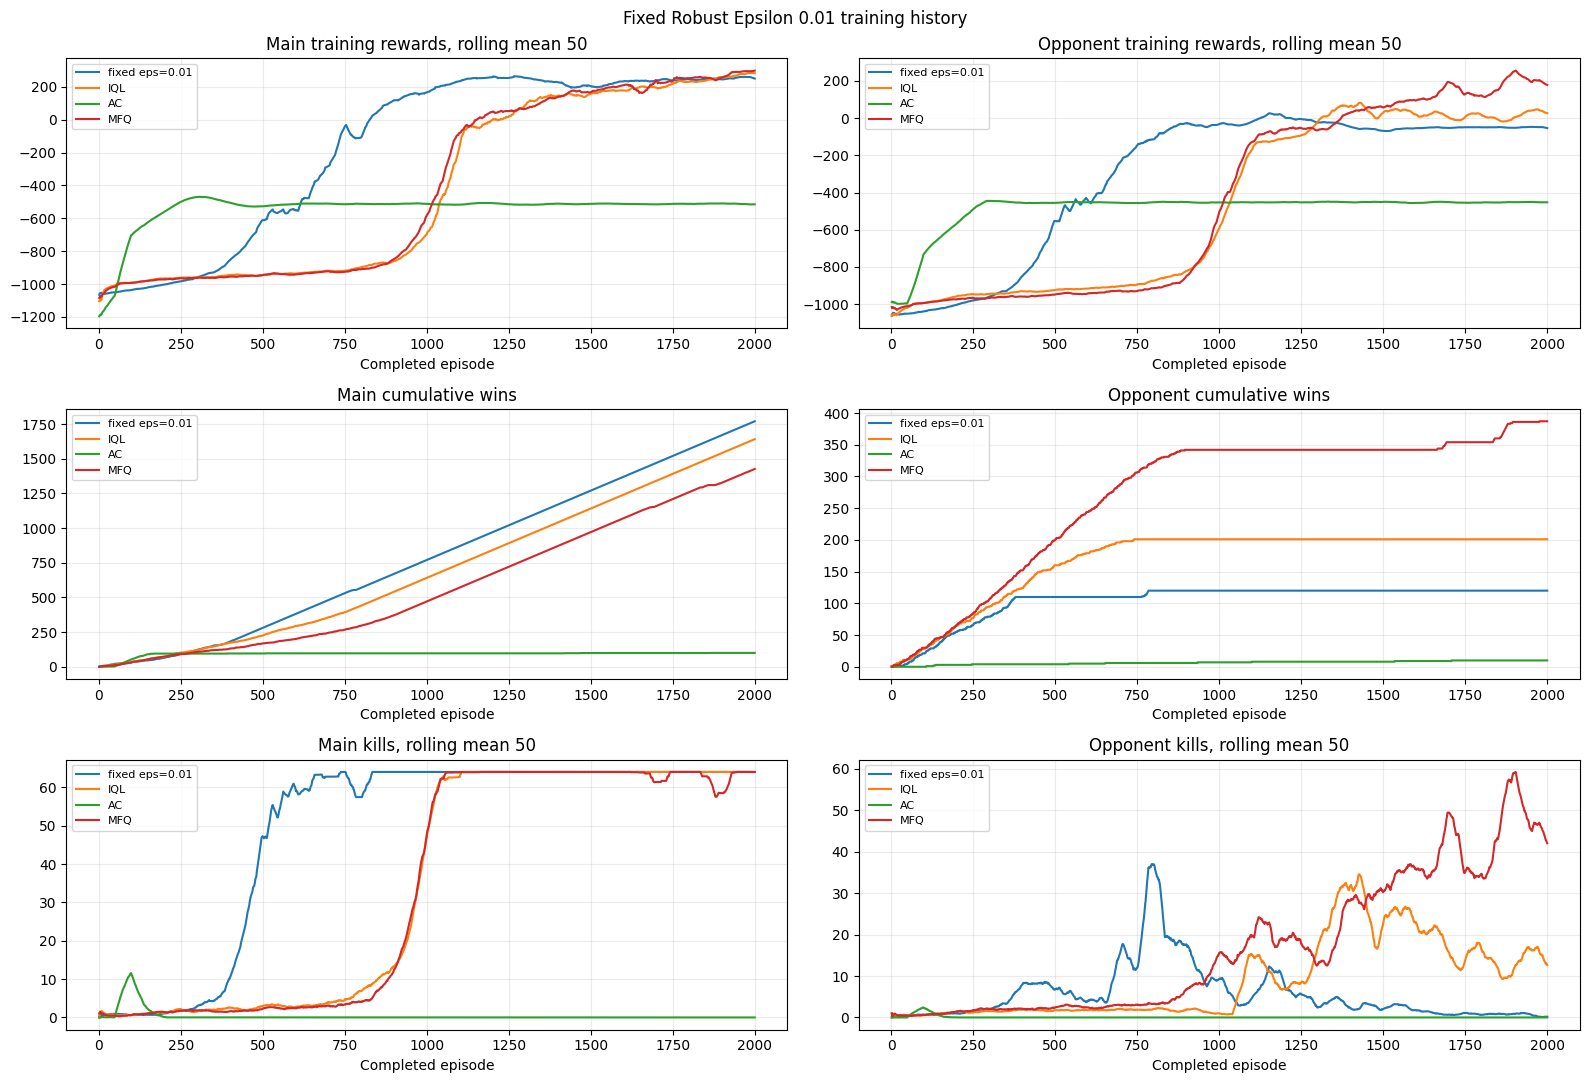

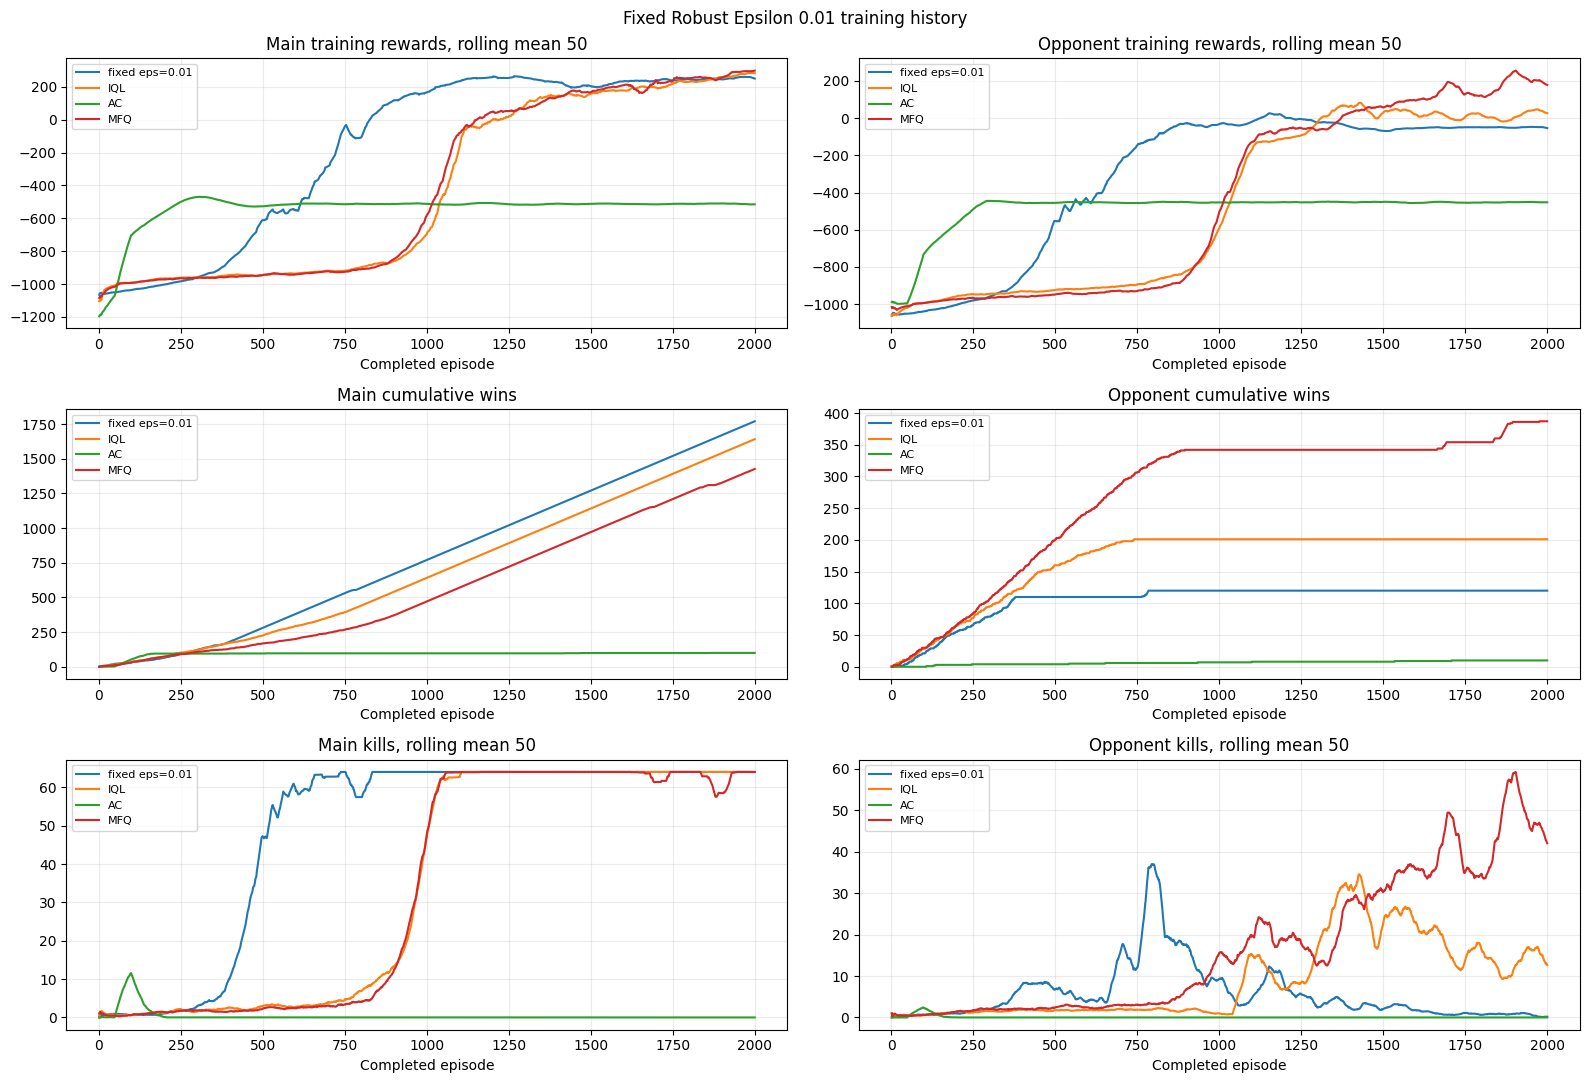

In [3]:
plot_training_history_group(
    ("fixed_0_01",),
    "Fixed Robust Epsilon 0.01 training history",
    "fixed_0_01_training_history",
)


## Fixed Robust Epsilon 0.1


In [ ]:
tournament_fixed_0_1 = evaluate_and_plot_model("fixed_0_1")
TOURNAMENTS["fixed_0_1"] = tournament_fixed_0_1
pd.DataFrame(tournament_fixed_0_1["rows"])


## Fixed Robust Epsilon 0.1 Training History


In [ ]:
plot_training_history_group(
    ("fixed_0_1",),
    "Fixed Robust Epsilon 0.1 training history",
    "fixed_0_1_training_history",
)


## Fixed Robust Epsilon 0.5


In [ ]:
tournament_fixed_0_5 = evaluate_and_plot_model("fixed_0_5")
TOURNAMENTS["fixed_0_5"] = tournament_fixed_0_5
pd.DataFrame(tournament_fixed_0_5["rows"])


## Fixed Robust Epsilon 0.5 Training History


In [ ]:
plot_training_history_group(
    ("fixed_0_5",),
    "Fixed Robust Epsilon 0.5 training history",
    "fixed_0_5_training_history",
)


## Fixed Robust Epsilon 1.0


In [ ]:
tournament_fixed_1_0 = evaluate_and_plot_model("fixed_1_0")
TOURNAMENTS["fixed_1_0"] = tournament_fixed_1_0
pd.DataFrame(tournament_fixed_1_0["rows"])


## Fixed Robust Epsilon 1.0 Training History


In [ ]:
plot_training_history_group(
    ("fixed_1_0",),
    "Fixed Robust Epsilon 1.0 training history",
    "fixed_1_0_training_history",
)


## Decay-to-Zero Robust Epsilon Tournaments


## Decay Robust Epsilon 0.5 -> 0


In [ ]:
tournament_decay_0_5_to_0 = evaluate_and_plot_model("decay_0_5_to_0")
TOURNAMENTS["decay_0_5_to_0"] = tournament_decay_0_5_to_0
pd.DataFrame(tournament_decay_0_5_to_0["rows"])


## Decay Robust Epsilon 0.5 -> 0 Training History


In [ ]:
plot_training_history_group(
    ("decay_0_5_to_0",),
    "Decay Robust Epsilon 0.5 -> 0 training history",
    "decay_0_5_to_0_training_history",
)


## Decay Robust Epsilon 0.75 -> 0


In [ ]:
tournament_decay_0_75_to_0 = evaluate_and_plot_model("decay_0_75_to_0")
TOURNAMENTS["decay_0_75_to_0"] = tournament_decay_0_75_to_0
pd.DataFrame(tournament_decay_0_75_to_0["rows"])


## Decay Robust Epsilon 0.75 -> 0 Training History


In [ ]:
plot_training_history_group(
    ("decay_0_75_to_0",),
    "Decay Robust Epsilon 0.75 -> 0 training history",
    "decay_0_75_to_0_training_history",
)


## Decay Robust Epsilon 1.0 -> 0


In [ ]:
tournament_decay_1_0_to_0 = evaluate_and_plot_model("decay_1_0_to_0")
TOURNAMENTS["decay_1_0_to_0"] = tournament_decay_1_0_to_0
pd.DataFrame(tournament_decay_1_0_to_0["rows"])


## Decay Robust Epsilon 1.0 -> 0 Training History


In [ ]:
plot_training_history_group(
    ("decay_1_0_to_0",),
    "Decay Robust Epsilon 1.0 -> 0 training history",
    "decay_1_0_to_0_training_history",
)


## Ramp-Up Robust Epsilon Tournaments


## Ramp Robust Epsilon 0.01 -> 0.5


In [ ]:
tournament_ramp_0_01_to_0_5 = evaluate_and_plot_model("ramp_0_01_to_0_5")
TOURNAMENTS["ramp_0_01_to_0_5"] = tournament_ramp_0_01_to_0_5
pd.DataFrame(tournament_ramp_0_01_to_0_5["rows"])


## Ramp Robust Epsilon 0.01 -> 0.5 Training History


In [ ]:
plot_training_history_group(
    ("ramp_0_01_to_0_5",),
    "Ramp Robust Epsilon 0.01 -> 0.5 training history",
    "ramp_0_01_to_0_5_training_history",
)


## Ramp Robust Epsilon 0.01 -> 1.0


In [ ]:
tournament_ramp_0_01_to_1_0 = evaluate_and_plot_model("ramp_0_01_to_1_0")
TOURNAMENTS["ramp_0_01_to_1_0"] = tournament_ramp_0_01_to_1_0
pd.DataFrame(tournament_ramp_0_01_to_1_0["rows"])


## Ramp Robust Epsilon 0.01 -> 1.0 Training History


In [ ]:
plot_training_history_group(
    ("ramp_0_01_to_1_0",),
    "Ramp Robust Epsilon 0.01 -> 1.0 training history",
    "ramp_0_01_to_1_0_training_history",
)


## Ramp Robust Epsilon 0.1 -> 0.5


In [ ]:
tournament_ramp_0_1_to_0_5 = evaluate_and_plot_model("ramp_0_1_to_0_5")
TOURNAMENTS["ramp_0_1_to_0_5"] = tournament_ramp_0_1_to_0_5
pd.DataFrame(tournament_ramp_0_1_to_0_5["rows"])


## Ramp Robust Epsilon 0.1 -> 0.5 Training History


In [ ]:
plot_training_history_group(
    ("ramp_0_1_to_0_5",),
    "Ramp Robust Epsilon 0.1 -> 0.5 training history",
    "ramp_0_1_to_0_5_training_history",
)


## Ramp Robust Epsilon 0.1 -> 1.0


In [ ]:
tournament_ramp_0_1_to_1_0 = evaluate_and_plot_model("ramp_0_1_to_1_0")
TOURNAMENTS["ramp_0_1_to_1_0"] = tournament_ramp_0_1_to_1_0
pd.DataFrame(tournament_ramp_0_1_to_1_0["rows"])


## Ramp Robust Epsilon 0.1 -> 1.0 Training History


In [ ]:
plot_training_history_group(
    ("ramp_0_1_to_1_0",),
    "Ramp Robust Epsilon 0.1 -> 1.0 training history",
    "ramp_0_1_to_1_0_training_history",
)


## Aggregate Table


In [ ]:
all_rows = []
for model_key, tournament in TOURNAMENTS.items():
    for row in tournament["rows"]:
        all_rows.append({
            "model_key": model_key,
            "model_label": MFDSRQ_MODEL_SPECS[model_key]["label"],
            **row,
        })
pd.DataFrame(all_rows)
